## Initialise Instruments

In [1]:
import qkit #filepath = r'C:\Users\weideslab-admin\AppData\Roaming\Python\Python313\site-packages\qkit\drivers

qkit.cfg['load_visa'] = True
qkit.cfg['datafolder_structure'] = 2
# New Qkit does not create folder. Must be done before run! (think a txt doc is created which causes this)
qkit.cfg['datadir'] = r'd:\notebooks\James'
qkit.cfg['run_id'] = 'results_h5'
qkit.cfg['user'] = 'James'
qkit.start()

from qkit.measure.spectroscopy import spectroscopy
from qkit.storage.store import Data
import qkit.measure.samples_class as sc
from qkit.analysis.circle_fit.circle_fit_2019 import circuit

# Uses SciPy for signal processing and curve fitting
from scipy import signal as sg
from scipy.optimize import curve_fit
import qkit.analysis.qfit as qfit

from importlib import reload
import qkit.gui.notebook.Progress_Bar as Pb
import qkit.measure.spectroscopy.spectroscopy as spectroscopy
from importlib import reload
import time

# import skrf as rf
import pyvisa as visa
from tqdm import tqdm
import requests

import mcculw # DAQ 
# import mcculw.ul
from attenuatorControl import ldacontroller #Dependency: import 'attenuatorControl' folder from existing working folders

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

import os
import re
import sys
import io



Lazy-Loading configuration...
QKIT configuration initialized -> available as qkit.cfg[...]
Starting QKIT framework ... -> qkit.core.startup
Loading module ... S10_logging.py
Loading module ... S14_setup_directories.py
Loading module ... S16_available_modules.py
Loading module ... S20_check_for_updates.py
Loading module ... S25_info_service.py
Loading module ... S30_qkit_start.py
Loading module ... S65_load_RI_service.py
Loading module ... S70_load_visa.py


C:\Users\weideslab-admin\AppData\Roaming\Python\Python313\site-packages\qkit\core\s_init\S70_load_visa.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


Loading module ... S80_load_file_service.py
Loading module ... S85_init_measurement.py


Loading module ... S98_started.py
Loading module ... S99_init_user.py
Initialized the file info database (qkit.fid) in 0.201 seconds.


### Instrument setup

In [39]:
rm = visa.ResourceManager() # Initialize the VISA library
resources = rm.list_resources() # List available VISA resources

for resource in resources: # Print the list of resources
    print(resource)

ASRL1::INSTR


In [40]:
# vna = qkit.instruments.create('vna', 'RS_VNA_ZNLXXX', address='GPIB0::20::INSTR') #R&S VNA via GPIB cable
#vna2 = qkit.instruments.create('vna2','RS_VNA_ZNLXXX',address='TCPIP::10.22.197.110::hislip0::INSTR') #R&S VNA via ethernet cable
#vna = vna2

#caen = qkit.instruments.create('caen', 'Caen_FAST_PS', address='10.22.197.101')
caen2040 = qkit.instruments.create('caen2', 'Caen_FAST_PS', address='10.22.197.103')

2026-09-11 15:02:55 [WARNING ]: Instrument "vna2" already exists, removing (instrument_tools.py:228)
2026-09-11 15:02:56 [WARNING ]: Instrument "caen2" already exists, removing (instrument_tools.py:228)


In [16]:
#ldacontroller.CLI_Vaunix_Attn().main(['-c', '1', '-a', '10'])

In [17]:
smpl = sc.Sample() # creates sample object (i.e., container for metadata)
s = spectroscopy.spectrum(vna = vna, exp_name = '', sample = smpl)

## Declare Functions

In [18]:
class dataset2d:  # for 2D sweeps (amplitude, frequency, current)

    def __init__(self, filepath, name):
        self.name = name

        with h5py.File(filepath, "r") as h5:
            self.amplitude = (20 * np.log10(np.array(h5["entry"]["data0"]["amplitude"])))
            self.frequency = (              np.array(h5["entry"]["data0"]["frequency"]) / 1e9)
            self.current =                  np.array(h5["entry"]["data0"]["current"])

    def subtract_background(self, background, name=None):
        corrected = np.empty_like(self.amplitude)

        # Match each frequency point to the closest
        # frequency point in the background.
        for j, freq in enumerate(self.frequency):
            freq_idx = np.abs(background.frequency - freq).argmin()

            # Subtract background from every current trace
            corrected[:, j] = (
                self.amplitude[:, j]
                - background.amplitude[freq_idx]
            )

        # Create a new dataset object without calling __init__
        result = dataset2d.__new__(dataset2d)

        result.name = (
            name if name
            else f"{self.name} - {background.name}"
        )

        result.frequency = self.frequency.copy()
        result.current = self.current.copy()
        result.amplitude = corrected

        return result

    def plot(self, current_index=0):
        """Plot amplitude vs frequency for one current value."""

        plt.figure(figsize=(6, 4))

        plt.plot(
            self.frequency,
            self.amplitude[current_index],
            lw=1.5
        )

        plt.xlabel("Frequency (GHz)")
        plt.ylabel("Amplitude (dB)")
        plt.title(
            f"{self.name} — "
            f"I = {self.current[current_index]:.4g}"
        )

        ax = plt.gca()

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

        ax.tick_params(direction="in")

        plt.tight_layout()
        plt.show()

    def plot2d(self):
        """Plot amplitude as a function of frequency and current."""

        plt.figure(figsize=(7, 5))

        plt.pcolormesh(
            self.frequency,
            self.current,
            self.amplitude,
            shading="auto",
            cmap="viridis"
        )

        plt.xlabel("Frequency (GHz)")
        plt.ylabel("Current")
        plt.title(self.name)

        cbar = plt.colorbar()
        cbar.set_label("Amplitude (dB)")

        ax = plt.gca()

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

        ax.tick_params(direction="in")

        plt.tight_layout()
        plt.show()


## Restart Instruments

In [19]:
vna.set_bandwidth(500)
vna.set_power(-20)
vna.set_startfreq(6.2e9) 
vna.set_stopfreq(6.45e9)
vna.set_nop(500)
vna.set_averages(1)
vna.set_sweep_mode('cont')

True

In [53]:
#ldacontroller.CLI_Vaunix_Attn().main(['-i', '32186', '-c', '1', '-a', str(0)])
#vna.set_sweep_mode('hold')
#caen.off()
caen2040.off()


True

## 1D Measurement (VNA Only)

In [16]:
def get_or_measure_1D(s, filename=None):
    """
    Load an existing 1D measurement HDF5 file or run the measurement if file doesn't exist.
    Returns:
        hdf: Data object
        amp_dB: amplitude in dB
        phase_deg: phase in degrees
        file_path: HDF5 filepath
    """
    if filename is not None and os.path.exists(filename):
        # File exists, just load
        print(f"Loading existing measurement from: {filename}")
        hdf = Data(filename)
        file_path = filename
    else:
        # File does not exist, run measurement
        print("File not found. Running 1D measurement...")
        # Capture printed output to get HDF5 path
        old_stdout = sys.stdout
        sys.stdout = mystdout = io.StringIO()

        s.measure_1D()
        
        sys.stdout = old_stdout
        output = mystdout.getvalue()
        
        # Extract HDF5 path from printed output
        match = re.search(r"(?:[a-zA-Z]:\\[^\s]+\.h5)", output)
        if not match:
            raise ValueError("Could not detect output HDF5 file path.")
        file_path = match.group(0)
        print(f"Measurement saved to: {file_path}")
        
        hdf = Data(file_path)
    # Extract amplitude and phase
    amp = np.transpose(hdf.data.amplitude[:])
    phase = np.transpose(hdf.data.phase[:])
    
    amp_dB = 20 * np.log10(amp)
    phase_deg = phase * 360 / (2*np.pi)
    
    return hdf, amp_dB, phase_deg, file_path

### Measure

HTML(value="<table style='width:100%'><tr><td> (0/1) </td><td>&#9992; 2026-08-13 (Thu) 12:14:55    </td><td>&#…

IntProgress(value=0, description='VNA_tracedata', layout=Layout(width='95%'), max=1)

File not found. Running 1D measurement...
Measurement saved to: d:\notebooks\James\RESULTS_H5\James\TJPGKU_VNA_tracedata\TJPGKU_VNA_tracedata.h5
0.0001


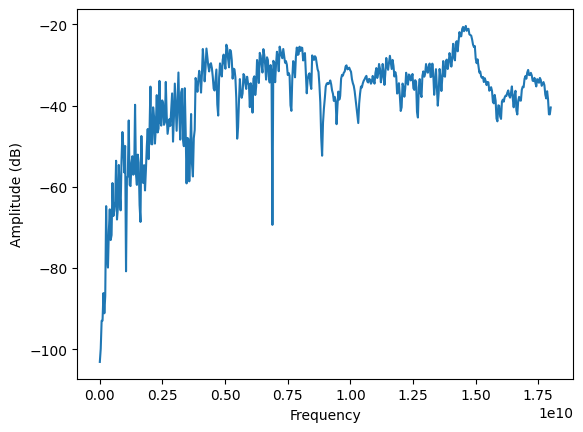

Plots saved in d:\notebooks\James\RESULTS_H5\James\TJPGKU_VNA_tracedata\images


KeyboardInterrupt: Interrupted by user

In [31]:
vna.set_bandwidth(500)
vna.set_power(-20)
vna.set_startfreq(100e3) 
vna.set_stopfreq(18e9)
vna.set_nop(500)
vna.set_averages(1)

vna.set_sweep_mode('cont')

s.set_resonator_fit(fit_resonator=False)

hdf, amp_dB, phase_deg, file = get_or_measure_1D(s)

vna.set_sweep_mode('hold')

freq = hdf.data.frequency[:]

res_index = np.argmin(amp_dB)
res_freq = freq[res_index]
print(res_freq/1e9)

plt.figure()
plt.plot(freq,amp_dB)
plt.xlabel("Frequency")
plt.ylabel("Amplitude (dB)")
plt.show()

# input("Add YIG sample and press continue")

# vna.set_sweep_mode('cont')

# s.set_resonator_fit(fit_resonator=False)

# hdf, amp_dB, phase_deg, file = get_or_measure_1D(s)

# vna.set_sweep_mode('hold')

# freq = hdf.data.frequency[:]

# res_index = np.argmin(amp_dB)
# res_freq = freq[res_index]
# print(res_freq/1e9)

# plt.figure()
# plt.plot(freq,amp_dB)
# plt.xlabel("Frequency")
# plt.ylabel("Amplitude (dB)")
# plt.show()



### Plot 

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:8: SyntaxWarning: invalid escape sequence '\J'
<>:9: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:8: SyntaxWarning: invalid escape sequence '\J'
<>:9: SyntaxWarning: invalid escape sequence '\J'
C:\Users\weideslab-admin\AppData\Local\Temp\ipykernel_11480\2192652673.py:1: SyntaxWarning: invalid escape sequence '\J'
  filename1 = "RESULTS_H5\James\TJ1NQM_VNA_tracedata\TJ1NQM_VNA_tracedata.h5" #TRANSDUCER V1 with YIG # possible systemic error, although placement of YIG on PCB matters
C:\Users\weideslab-admin\AppData\Local\Temp\ipykernel_11480\2192652673.py:2: SyntaxWarning: invalid escape sequence '\J'
  filename1 = "RESULTS_H5\James\TJPGFM_VNA_tracedata\TJPGFM_VNA_tracedata.h5" #TRANSDUCER V1 BIG MAGNET #1
C:\Users\weideslab-admin\AppData\Local\Temp\ipykernel_11480\2192652673.py:8: Synt

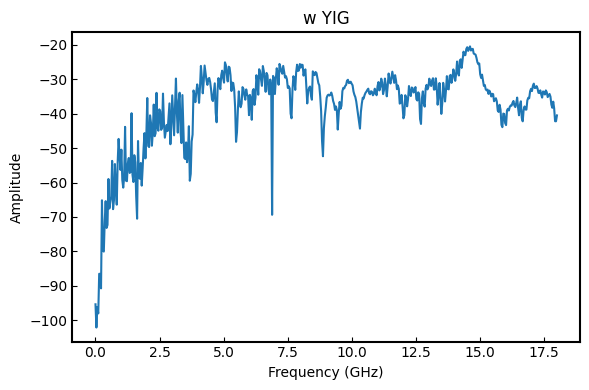

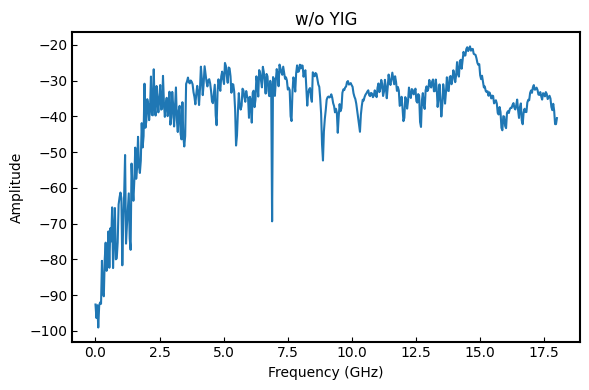

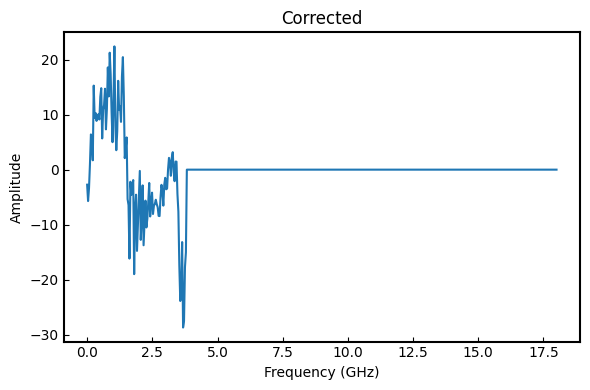

In [34]:
filename1 = "RESULTS_H5\James\TJ1NQM_VNA_tracedata\TJ1NQM_VNA_tracedata.h5" #TRANSDUCER V1 with YIG # possible systemic error, although placement of YIG on PCB matters
filename1 = "RESULTS_H5\James\TJPGFM_VNA_tracedata\TJPGFM_VNA_tracedata.h5" #TRANSDUCER V1 BIG MAGNET #1 - yig

#filename1 = "RESULTS_H5\James\TJ1Q81_VNA_tracedata\TJ1Q81_VNA_tracedata.h5" #TRANSDUCER V1 with YIG v2a -control
#filename1 = "RESULTS_H5\James\TJ1Q8E_VNA_tracedata\TJ1Q8E_VNA_tracedata.h5" #TRANSDUCER V1 with YIG v2b -control
#filename1 = "RESULTS_H5\James\TJ1QIA_VNA_tracedata\TJ1QIA_VNA_tracedata.h5" #TRANSDUCER V1 with YIG - suboptimal placement

filename2 = "RESULTS_H5\James\TJ1NPW_VNA_tracedata\TJ1NPW_VNA_tracedata.h5" #TRANSDUCER V1 without YIG - control
filename2 = "RESULTS_H5\James\TJPGEG_VNA_tracedata\TJPGEG_VNA_tracedata.h5" #TRANSDUCER V1 BIG MAGNET #1 - control
exp = dataset2d(filename1, "w YIG")
exp.plot()
base = dataset2d(filename2, "w/o YIG")
base.plot()
corrected = exp.subtract_background(base, name="Corrected")
corrected.plot()

## 2D Measurement (VNA + Small MAGNET)

In [ ]:
# ///////////////////// SETUP ////////////////////////////////////////////////////////////////////////////////////////////
vna.set_bandwidth(30)
# vna.set_bandwidth(500)
vna.set_power(-10)
# vna.set_nop(1000)
# vna.set_averages(1)
vna.set_startfreq(2e9) 
vna.set_stopfreq(8e9)

# ldacontroller.CLI_Vaunix_Attn().main(['-c', '1', '-a', '0']) #digital attenuator

s.set_resonator_fit(fit_resonator=False)

caen.on()
caen.ramp_current(1.5, 0.5)

def x_func(i):
    caen.ramp_current(i, 1e-1) 
    return

# s.set_x_parameters(x_vec = np.arange(0, 4.8, 0.005),
s.set_x_parameters(x_vec = np.arange(1, 5, 0.5),
                   x_coordname = 'current',
                   x_set_obj = x_func,
                   x_unit = 'A')

# //////////////////// MEASURE ///////////////////////////////////////////////////////////////////////////////////////////

vna.set_sweep_mode('cont') 
s.measure_2D()

# ////////////////// SAFE SYSTEM ///////////////////////////////////////////////////////////////////////////////////////////
vna.set_power(-22)
caen.ramp_current(0.0, 1)
vna.set_sweep_mode('hold')
#ldacontroller.CLI_Vaunix_Attn().main(['-c', '1', '-a', str(50)])
caen.off()

### Plot

In [ ]:
base_filepath = "RESULTS_H5\James\TJ1MMK_2D_current\TJ1MMK_2D_current.h5" #TRASNDUCER V1 - BASE

filepath = "RESULTS_H5\James\TJ1MYI_2D_current\TJ1MYI_2D_current.h5" #TRANSDUCER V1 - FMR #2a - experiments w & w/o YIG give different PCB modes- readjusted sample location away from stubs in attempt to fix
filepath = "RESULTS_H5\James\TJ1N6N_2D_current\TJ1N6N_2D_current.h5" #TRANSDUCER V1 - FMR #2b - different modes again irrespective of magnet, remove stand from experimental setup and reattempt 



## 2D MEASUREMENT (VNA + BIG MAGNET)

In [37]:
# ///////////////////// SETUP ////////////////////////////////////////////////////////////////////////////////////////////
vna.set_bandwidth(10)
#vna.set_bandwidth(500)
vna.set_power(-10)
vna.set_nop(10000)
vna.set_averages(5)
vna.set_startfreq(3.35e9) 
vna.set_stopfreq(3.55e9)

# ldacontroller.CLI_Vaunix_Attn().main(['-c', '1', '-a', '0']) #digital attenuator

s.set_resonator_fit(fit_resonator=False)

caen2040.on()
caen2040.ramp_current(1.0, 0.5)

def x_func(i):
    caen2040.ramp_current(i, 1e-1) 
    return

# s.set_x_parameters(x_vec = np.arange(0, 4.8, 0.005),
s.set_x_parameters(x_vec = np.arange(1.175, 1.176, 0.0001),
                   x_coordname = 'current',
                   x_set_obj = x_func,
                   x_unit = 'A')

# //////////////////// MEASURE ///////////////////////////////////////////////////////////////////////////////////////////

vna.set_sweep_mode('cont') 
s.measure_2D() 

# ////////////////// SAFE SYSTEM ///////////////////////////////////////////////////////////////////////////////////////////
vna.set_power(-22)
caen2040.ramp_current(0.0, 1)
vna.set_sweep_mode('hold')
#ldacontroller.CLI_Vaunix_Attn().main(['-c', '1', '-a', str(50)])
caen2040.off()

HTML(value="<table style='width:100%'><tr><td> (0/10) </td><td>&#9992; 2026-09-10 (Thu) 21:07:55    </td><td>&…

IntProgress(value=0, description='2D VNA sweep current', layout=Layout(width='95%'), max=10)

Could not retrieve options for parameter port1_edel
Could not retrieve options for parameter port2_edel
d:\notebooks\James\RESULTS_H5\James\TL5G8A_2D_current\TL5G8A_2D_current.h5
Plots saved in d:\notebooks\James\RESULTS_H5\James\TL5G8A_2D_current\images


True

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\weideslab-admin\AppData\Local\Temp\ipykernel_11480\1088081538.py:1: SyntaxWarning: invalid escape sequence '\J'
  filepath = "results_h5\James\TJPONP_2D_current\TJPONP_2D_current.h5"
C:\Users\weideslab-admin\AppData\Local\Temp\ipykernel_11480\1088081538.py:1: SyntaxWarning: invalid escape sequence '\J'
  filepath = "results_h5\James\TJPONP_2D_current\TJPONP_2D_current.h5"


ValueError: x and y must have same first dimension, but have shapes (1000,) and (775, 1000)

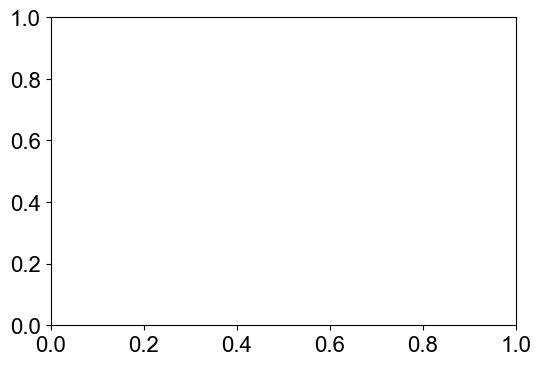

In [67]:
filepath = "results_h5\James\TJPONP_2D_current\TJPONP_2D_current.h5"

data = dataset2d(filepath, 'data')

data.plot2d()

In [59]:
caen2040.ramp_current(0.0, 1)
caen2040.off()

True

### Kittel Mode Calculation

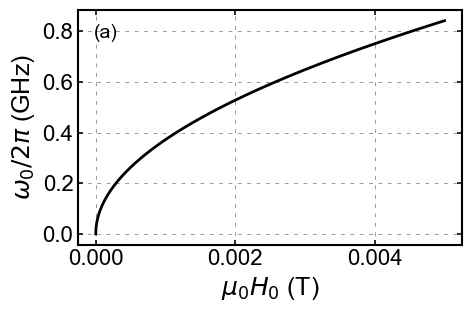

In [52]:
# That equation using comes from page 464 in Pozars Microwave Engineering text book
# Check out Fundamentals of Magnonics by Rezende page 12
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
 
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 16
 
 
mu0_Ms = 0.1758       # [T]
gamma_2pi = 28.0      # [GHz/T]
Dz = 1.0
Dx = 0.0
Dy = 0.0
u0H0 = np.linspace(0.0, 0.005, 1000) # Applied field [T]
 
# Kittel mode
# f_GHz = gamma_2pi * (u0H0 - mu0_Ms)
f_GHz = gamma_2pi * np.sqrt(u0H0 * (u0H0 + mu0_Ms))
 
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(u0H0, f_GHz, color='black', lw=2.0)
# ax.set_xlim(0, 0.6)
ax.set_xlabel(r'$\mu_0 H_0$ (T)', fontsize=18)
ax.set_ylabel(r'$\omega_0 / 2\pi$ (GHz)', fontsize=18)
ax.text(0.04, 0.88, '(a)', transform=ax.transAxes, fontsize=14)
ax.tick_params(direction='in', which='major', top=True, right=True, bottom=True, left=True, width=1.15)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.grid(True, color='#727271', linestyle='--', linewidth=0.5, dashes=(5.5, 8))
fig.tight_layout()
plt.show()
 

## FPGA Startup

### Setup

In [41]:
# Control PC logging - set to True for debugging, False for clean output
ENABLE_PC_LOGS = False

def log_print(*args, **kwargs):
    """Print only if logging is enabled"""
    if ENABLE_PC_LOGS:
        print(*args, **kwargs)

In [42]:
def wait_for_fpga_ready(timeout=60):
    """Wait for FPGA to signal it's ready"""
    start_time = time.time()
    while time.time() - start_time < timeout:
        try:
            response = requests.get('http://10.22.197.200:5000/ready', timeout=2)
            data = response.json()
            if data['ready']:
                return True, data.get('data', None)
        except Exception as e:
            print(f"Connection error: {e}")
            pass
        time.sleep(0.5)
    return False, None

def reset_fpga_flag():
    """Tell FPGA we're ready for the next measurement"""
    try:
        response = requests.get('http://10.22.197.200:5000/reset', timeout=2)
        return response.json()['status'] == 'reset'
    except:
        return False

def test_connection():
    """Test if FPGA server is running"""
    try:
        response = requests.get('http://10.22.197.200:5000/status', timeout=2)
        return response.json()['server'] == 'running'
    except:
        return False

In [43]:
if test_connection():
    print("✅ Connection to FPGA established!")
else:
    print("❌ Cannot connect to FPGA. Make sure Flask server is running.")

❌ Cannot connect to FPGA. Make sure Flask server is running.


### FPGA class

5/10/26: Based on need to do understand the operation and need to perform complex tasks with the FPGA, an FPGA class should be made. 

The FPGA class should be based on communication via flask server, the fpga should be perform a measurement and send the data to the PC for the PC to process*.

*Even though the FPGA is capable of doing data processing, splitting the workload across both the PC and the FPGA is impractical and gives rise to parity issues, this is an issue that can be amplified as it is an arbitrary process made susceptible to user preference with no straightforward way to resolve. 

In [ ]:
class FPGA():
    

### Establish Connection

In [47]:
# Test if it's really working
try:
    response = requests.get('http://10.22.197.200:5000/ready', timeout=2)
    print("Ready endpoint response:", response.json())
    
    # Try to reset
    response = requests.get('http://10.22.197.200:5000/reset', timeout=2)
    print("Reset endpoint response:", response.json())
    
    print("✅ Server is actually running and functional")
except Exception as e:
    print("❌ Server not fully functional:", e)

Ready endpoint response: {'data': None, 'ready': True}
Reset endpoint response: {'status': 'reset'}
✅ Server is actually running and functional


## FPGA + Big MAGNET

Ensure 'FPGA Startup' Blocks are run before this

In [55]:
ENABLE_PC_LOGS = False
caen2 = caen2040
# start_value = 2.77 # Define the start value
# end_value = 2.96 # Define the end value
# noOfSteps = 60       # Define the number of steps
# currents = np.linspace(start_value, end_value, noOfSteps)
caen2_current = np.arange(-0.75, 5.0, 0.01)
currents = caen2_current

# Send currents array to FPGA
response = requests.post("http://10.22.197.200:5000/set_currents", 
                        json={'currents': currents.tolist()})
print(f"Sent {len(currents)} current values to FPGA")
caen2_currents_FPGA = currents



# Initialize CAEN
caen2.on()
start_i = np.floor(currents[0] * 10) / 10
caen2.ramp_current(start_i, 0.5)
# for _ in tqdm(range(2), desc="Pre-conditioning magnet"):
#     caen2.ramp_current(currents[0], 0.005)
#     caen2.ramp_current(currents[-1], 0.005)
caen2.ramp_current(currents[0], 0.005)

for idx, i in enumerate(tqdm(currents)):
    log_print(f"\n--- Step {idx+1}/{len(currents)}: Setting current to {i} ---")
    
    # Set the new current
    caen2.ramp_current(i, 0.05)
    log_print(f"Current set to {i}, FPGA can now measure...")
    
    # Signal FPGA that current is set
    if reset_fpga_flag():
        log_print("✅ Current set, FPGA can measure")
    
    # Wait for FPGA to complete its measurement
    ready, fpga_data = wait_for_fpga_ready(timeout=120)
    if ready:
        log_print(f"✅ FPGA measurement complete!")
        if fpga_data and ENABLE_PC_LOGS:
            log_print(f"   Max signal: {fpga_data.get('max_signal', 'N/A')}")
        
        # Signal FPGA that we're ready for the next measurement
        if reset_fpga_flag():
            log_print("✅ FPGA reset for next measurement")
        else:
            print("⚠️  Could not reset FPGA flag")
    else:
        print("❌ Timeout waiting for FPGA!")
        break

requests.post("http://10.22.197.200:5000/pc_done")
print("Loop completed.")
# caen.ramp_current(0.0, 0.5)
caen2.ramp_current(0.0, 0.5)
# caen.off()
caen2.off()

Sent 575 current values to FPGA


100%|███████████████████████████████████████████████████████████████████████| 575/575 [53:12<00:00,  5.55s/it]


Loop completed.


True

## FPGA + Big Magnet v2 

In [65]:
import h5py
from datetime import datetime

ENABLE_PC_LOGS = False
caen2 = caen2040
data_dir = "./results_h5/JamesFPGA"

# Current sweep
currents = np.arange(-0.75, 5.0, 0.05)

requests.post(
    "http://10.22.197.200:5000/set_currents",
    json={"currents": currents.tolist()}
)
print(f"Sent {len(currents)} current values to FPGA")

# Storage
all_amplitudes = []
all_phases = []
measured_currents = []
timestamps = []
iterations = []
frequencies = None

# Initialise CAEN
caen2.on()
start_i = np.floor(currents[0] * 10) / 10
caen2.ramp_current(start_i, 0.5)
caen2.ramp_current(currents[0], 0.005)

# Measurement loop
for idx, i in enumerate(tqdm(currents)):
    log_print(f"\n--- Step {idx+1}/{len(currents)}: Setting current to {i} ---")

    caen2.ramp_current(i, 0.05)

    if reset_fpga_flag():
        log_print("✅ Current set, FPGA can measure")

    ready, fpga_data = wait_for_fpga_ready(timeout=120)

    if not ready:
        print("❌ Timeout waiting for FPGA!")
        break

    print("✅ FPGA measurement complete")

    if fpga_data:
        if frequencies is None:
            frequencies = np.asarray(fpga_data["frequencies"], dtype=np.float64)

        all_amplitudes.append(np.asarray(fpga_data["amps"]))
        all_phases.append(np.asarray(fpga_data["phases"]))
        measured_currents.append(i)
        timestamps.append(fpga_data.get("timestamp", time.time()))
        iterations.append(fpga_data.get("iteration", idx))

        if ENABLE_PC_LOGS:
            print("Max signal:", fpga_data.get("max_signal", "N/A"))

    if reset_fpga_flag():
        log_print("✅ FPGA reset for next measurement")
    else:
        print("⚠️ Could not reset FPGA flag")

# Save HDF5
if all_amplitudes:
    amplitude = np.asarray(all_amplitudes)
    phase = np.asarray(all_phases)
    measured_currents = np.asarray(measured_currents)
    timestamps = np.asarray(timestamps)
    iterations = np.asarray(iterations)

    filename = datetime.now().strftime("fpga_%Y%m%d_%H%M%S.h5")
    filepath = os.path.join(data_dir, filename)

    with h5py.File(filepath, "w") as f:
        f.create_dataset("currents", data=measured_currents)
        f.create_dataset("frequencies", data=frequencies)
        f.create_dataset("amplitude", data=amplitude)
        f.create_dataset("phase", data=phase)
        f.create_dataset("timestamps", data=timestamps)
        f.create_dataset("iterations", data=iterations)
        f.attrs["measurement_date"] = datetime.now().isoformat()

    print(f"✅ Data saved to {filename}")
    print("Amplitude shape:", amplitude.shape)
    print("Phase shape:", phase.shape)
else:
    print("❌ No measurement data received")

# Finish
requests.post("http://10.22.197.200:5000/pc_done")
print("Loop completed.")

caen2.ramp_current(0.0, 0.5)
caen2.off()





Sent 115 current values to FPGA


  1%|▋                                                                        | 1/115 [00:05<10:29,  5.52s/it]

✅ FPGA measurement complete


  2%|█▎                                                                       | 2/115 [00:10<10:15,  5.44s/it]

✅ FPGA measurement complete


...

 99%|██████████████████████████████████████████████████████████████████████▍| 114/115 [10:08<00:05,  5.33s/it]

✅ FPGA measurement complete


100%|███████████████████████████████████████████████████████████████████████| 115/115 [10:13<00:00,  5.34s/it]

✅ FPGA measurement complete
✅ Data saved to measurement_20261001_174908.h5
Amplitude shape: (115, 25, 100)
Phase shape: (115, 25, 100)
Loop completed.


True

In [64]:
caen2.off()

True